# Data Privacy Analysis

## Proyecto: Privacy Healthcare Audit

En este notebook se clasifican los datos del dataset según su nivel de sensibilidad, con el objetivo de identificar riesgos de privacidad y exposición de información.

### Objetivos
- Identificar datos personales
- Identificar datos sensibles
- Clasificar cada atributo
- Preparar base para análisis de riesgo

In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/healthcare_eda_processed.csv")

df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20


In [4]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results', 'Length of Stay'],
      dtype='str')

In [5]:
classification = {
    "Name": "Personal Directo",
    "Age": "Cuasi Identificador",
    "Gender": "Cuasi Identificador",
    "Blood Type": "Dato Sensible",
    "Medical Condition": "Dato Sensible",
    "Date of Admission": "Dato Operacional",
    "Doctor": "Dato Personal",
    "Hospital": "Dato Operacional",
    "Insurance Provider": "Dato Financiero",
    "Billing Amount": "Dato Financiero",
    "Room Number": "Dato Operacional",
    "Admission Type": "Dato Operacional",
    "Discharge Date": "Dato Operacional",
    "Medication": "Dato Sensible",
    "Test Results": "Dato Sensible",
    "Length of Stay": "Dato Derivado"
}

In [6]:
classification_df = pd.DataFrame(
    list(classification.items()),
    columns=["Campo", "Tipo de Dato"]
)

classification_df

,Campo,Tipo de Dato
0,Name,Personal Directo
1,Age,Cuasi Identificador
2,Gender,Cuasi Identificador
3,Blood Type,Dato Sensible
4,Medical Condition,Dato Sensible
5,Date of Admission,Dato Operacional
6,Doctor,Dato Personal
7,Hospital,Dato Operacional
8,Insurance Provider,Dato Financiero
9,Billing Amount,Dato Financiero


In [7]:
classification_df["Tipo de Dato"].value_counts()

Tipo de Dato
Dato Operacional       5
Dato Sensible          4
Cuasi Identificador    2
Dato Financiero        2
Personal Directo       1
Dato Personal          1
Dato Derivado          1
Name: count, dtype: int64

<Axes: title={'center': 'Clasificación de tipos de datos'}, xlabel='Tipo de Dato'>

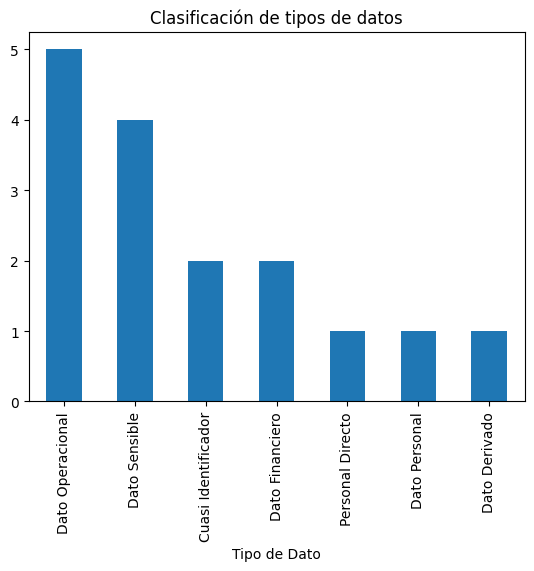

In [8]:
classification_df["Tipo de Dato"].value_counts().plot(
    kind="bar",
    title="Clasificación de tipos de datos"
)

In [9]:
sensitive_cols = classification_df[
    classification_df["Tipo de Dato"] == "Dato Sensible"
]["Campo"].tolist()

sensitive_cols

['Blood Type', 'Medical Condition', 'Medication', 'Test Results']

In [10]:
df[sensitive_cols].head()

,Blood Type,Medical Condition,Medication,Test Results
0,B-,Cancer,Paracetamol,Normal
1,A+,Obesity,Ibuprofen,Inconclusive
2,A-,Obesity,Aspirin,Normal
3,O+,Diabetes,Ibuprofen,Abnormal
4,AB+,Cancer,Penicillin,Abnormal


In [11]:
personal_cols = classification_df[
    classification_df["Tipo de Dato"].isin([
        "Personal Directo",
        "Cuasi Identificador"
    ])
]["Campo"].tolist()

personal_cols

['Name', 'Age', 'Gender']

In [12]:
df[personal_cols].head()

,Name,Age,Gender
0,Bobby JacksOn,30,Male
1,LesLie TErRy,62,Male
2,DaNnY sMitH,76,Female
3,andrEw waTtS,28,Female
4,adrIENNE bEll,43,Female


In [13]:
risk_mapping = {
    "Personal Directo": 5,
    "Dato Sensible": 5,
    "Cuasi Identificador": 4,
    "Dato Financiero": 4,
    "Dato Operacional": 2,
    "Dato Derivado": 1
}

classification_df["Nivel Riesgo"] = classification_df["Tipo de Dato"].map(risk_mapping)

classification_df

,Campo,Tipo de Dato,Nivel Riesgo
0,Name,Personal Directo,5.0
1,Age,Cuasi Identificador,4.0
2,Gender,Cuasi Identificador,4.0
3,Blood Type,Dato Sensible,5.0
4,Medical Condition,Dato Sensible,5.0
5,Date of Admission,Dato Operacional,2.0
6,Doctor,Dato Personal,NaN
7,Hospital,Dato Operacional,2.0
8,Insurance Provider,Dato Financiero,4.0
9,Billing Amount,Dato Financiero,4.0


In [14]:
classification_df["Nivel Riesgo"].mean()

np.float64(3.466666666666667)

In [15]:
import os

os.makedirs("../data/processed", exist_ok=True)

classification_df.to_csv("../data/processed/privacy_classification.csv", index=False)

## Hallazgos de Privacidad

- Se identificaron múltiples campos clasificados como datos sensibles, incluyendo:
  - Medical Condition
  - Medication
  - Test Results
  - Blood Type

- Existen datos personales directos que permiten identificar individuos.

- La combinación de cuasi identificadores (edad, género) con datos sensibles incrementa el riesgo de reidentificación.

- Se identifican datos financieros que también representan riesgo adicional.

### Conclusión

El dataset presenta un nivel de riesgo medio-alto desde una perspectiva de privacidad, por lo que se recomienda aplicar controles como:
- enmascaramiento de datos
- anonimización
- control de accesos